# ABLE: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/ABLE](https://github.com/Mishrakshitij/ABLE)    
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'ABLE'
COMMIT = 'ade75e9773bfc9206e2ff64e170b8452b6252864'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: ade75e9773bfc9206e2ff64e170b8452b6252864
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"torch>=2.6,<3",2.13.0+cu129,True
1,"transformers>=4.48,<6",4.57.6,True
2,"peft>=0.14,<1",0.18.1,True
3,"accelerate>=1.2,<2",1.14.0,True
4,"numpy>=1.24,<3",2.3.5,True
5,"matplotlib>=3.7,<4",3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# ABLE: repository executability study
This study uses the released PERPDSCD data and the repository's supervised
response-training, checkpoint-loading, generation, and evaluation functions.
A downloaded `sshleifer/tiny-gpt2` backbone replaces Phi-2 to keep the check
small. The scope is five LoRA optimizer updates and four held-out responses.
This establishes execution of the supervised pathway; it does not establish
paper-level quality or execution of the optional classifiers and PPO stage.

In [ ]:
import importlib.metadata as metadata
import json
import math
from pathlib import Path
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import torch
from torch.optim.optimizer import register_optimizer_step_post_hook

sys.path.insert(0, str(REPO_ROOT / "src"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from able.data import iter_examples, verify_dataset
from able.training import train_sft, evaluate_sft
from able.inference import load_checkpoint, generate_dataset
from able.evaluation import evaluate_predictions

COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
VERSIONS = {name: metadata.version(name) for name in ("torch", "transformers", "peft", "numpy", "pandas", "matplotlib")}
print("Repository: Mishrakshitij/ABLE | revision:", COMMIT)
print("Backbone:", CAUSAL_MODEL, "| device:", DEVICE)
display(pd.Series(VERSIONS, name="Installed version").to_frame())

Repository: Mishrakshitij/ABLE | revision: ade75e9773bfc9206e2ff64e170b8452b6252864
Backbone: sshleifer/tiny-gpt2 | device: cuda


,Installed version
torch,2.13.0+cu129
transformers,4.57.6
peft,0.18.1
numpy,2.3.5
pandas,3.0.5
matplotlib,3.10.7


## Dataset integrity and exploratory analysis
Native verification checks the shipped CSV schemas, manifest checksums,
conversation splits, and label ranges. Full-corpus counts are distinguished
from the small training and evaluation selections below. The label plots also
reveal severe class imbalance, which limits what a tiny execution check can
say about learned behavior.

,conversations,utterances,doctor_responses
train,14420,322427,160666
validation,1803,40350,20103
test,1803,40308,20073


Dataset integrity: PASS


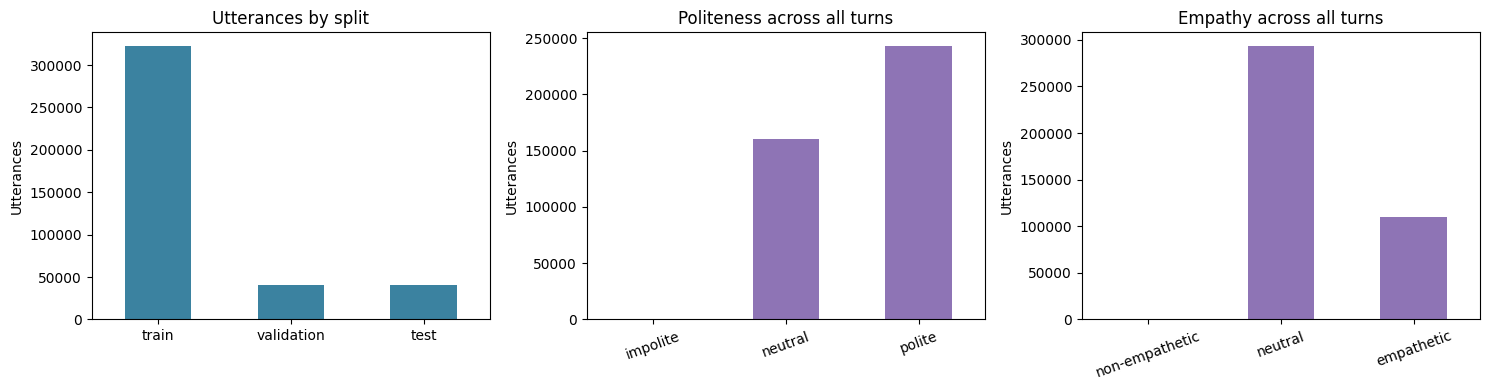

In [ ]:
DATA = REPO_ROOT / "datasets"
integrity = verify_dataset(DATA)
assert integrity["valid"] and not integrity["errors"], integrity.get("errors")
split_table = pd.DataFrame({split: {key: values[key] for key in
    ("conversations", "utterances", "doctor_responses")}
    for split, values in integrity["splits"].items()}).T
display(split_table)
print("Dataset integrity: PASS")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
split_table["utterances"].plot.bar(ax=axes[0], color="#3b82a0", rot=0, title="Utterances by split")
for axis, field, labels, title in (
    (axes[1], "politeness_label", ["impolite", "neutral", "polite"], "Politeness across all turns"),
    (axes[2], "empathy_label", ["non-empathetic", "neutral", "empathetic"], "Empathy across all turns"),
):
    values = [sum(part["labels"][field].get(str(i), 0) for part in integrity["splits"].values()) for i in range(3)]
    pd.Series(values, index=labels).plot.bar(ax=axis, color="#8e74b5", rot=20, title=title)
for axis in axes:
    axis.set_ylabel("Utterances")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset-overview.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
train_examples = list(iter_examples(DATA, "train", max_examples=10))
validation_examples = list(iter_examples(DATA, "validation", max_examples=4))
test_examples = list(iter_examples(DATA, "test", max_examples=4))
assert len(train_examples) == 10 and len(validation_examples) == len(test_examples) == 4
assert {x.conversation_id for x in train_examples}.isdisjoint(x.conversation_id for x in test_examples)
display(pd.DataFrame([{"split": split, "selected responses": len(rows)} for split, rows in
    (("train", train_examples), ("validation", validation_examples), ("test", test_examples))]))
display(pd.DataFrame([{"example_id": x.example_id, "prompt excerpt": x.prompt[:240],
                       "reference excerpt": x.response[:240]} for x in train_examples[:3]]))

,split,selected responses
0,train,10
1,validation,4
2,test,4


,example_id,prompt excerpt,reference excerpt
0,1:2,Gender: Male\nAge: Younger\nPersona: High Open...,"Hello, Mr. Johnson. I'm here to help. Please t..."
1,1:4,Gender: Male\nAge: Younger\nPersona: High Open...,"I understand, Mr. Johnson. It's common for mob..."
2,1:6,Gender: Male\nAge: Younger\nPersona: High Open...,"Excellent, Mr. Johnson. We can start with gent..."


## Native supervised training: five updates
The repository trains response tokens only, while masking context and padding.
The only model adaptation is a small LoRA configuration targeting GPT-2's
`c_attn` modules. An optimizer hook observes actual completed updates; the
repository's returned step count and saved optimizer state provide additional
checks. Validation is limited to four released validation examples.

In [ ]:
CHECKPOINT = OUTPUT_DIR / "checkpoint"
config = {
    "data": {"path": str(DATA), "train_split": "train", "validation_split": "validation",
             "max_examples": 10, "max_validation_examples": 4},
    "model": {"name": CAUSAL_MODEL, "device": DEVICE, "dtype": "float32",
              "lora": {"enabled": True, "r": 2, "lora_alpha": 4, "lora_dropout": 0.0,
                       "target_modules": ["c_attn"]}},
    "training": {"output_dir": str(CHECKPOINT), "epochs": 1, "batch_size": 2,
                 "gradient_accumulation_steps": 1, "max_steps": 5, "max_length": 96,
                 "learning_rate": 5e-4, "logging_steps": 1, "seed": 42},
}
observed_steps = []
step_hook = register_optimizer_step_post_hook(lambda *args, **kwargs: observed_steps.append(len(observed_steps) + 1))
started = time.perf_counter()
try:
    training = train_sft(config)
finally:
    step_hook.remove()
training_seconds = time.perf_counter() - started
assert training["steps"] == len(observed_steps) == 5
assert all(math.isfinite(float(training[key])) for key in ("train_response_nll", "validation_response_nll"))
display(pd.DataFrame([training]))
print("Observed optimizer updates:", len(observed_steps))

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`torch_dtype` is deprecated! Use `dtype` instead!


No prebuilt binary for CUDA 12.9, loading CUDA 12.8 instead. Set BNB_CUDA_VERSION to override.


./.venv/lib/python3.11/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


...

{"step": 4, "epoch": 1, "train_response_nll": 10.820964682335948}


{"step": 5, "epoch": 1, "train_response_nll": 10.821422967884349}


./.venv/lib/python3.11/site-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in sshleifer/tiny-gpt2 - will assume that the vocabulary was not modified.
  warnings.warn(


,steps,examples_seen,train_response_nll,validation_response_nll,validation_token_perplexity,validation_tokens
0,5,10,10.821423,10.824453,50234.267157,117


Observed optimizer updates: 5


## Saved checkpoint and native reload
Reloading from the saved adapter verifies the complete base-model-plus-adapter
loading path. A finite held-out reference loss and nonzero trained LoRA weights
check that the artifact is usable after training.

In [ ]:
assert (CHECKPOINT / "adapter_config.json").is_file()
assert (CHECKPOINT / "adapter_model.safetensors").is_file()
saved_optimizer = torch.load(CHECKPOINT / "optimizer.pt", map_location="cpu", weights_only=True)
assert saved_optimizer["step"] == 5
model, tokenizer = load_checkpoint(str(CHECKPOINT), device=DEVICE)
parameter_count = sum(p.numel() for p in model.parameters())
assert any(torch.count_nonzero(p).item() > 0 for name, p in model.named_parameters() if "lora_B" in name)
heldout_reference = evaluate_sft(model, tokenizer, test_examples, batch_size=2, max_length=96)
assert math.isfinite(heldout_reference["validation_response_nll"])
print("Checkpoint save/reload: PASS | parameters:", parameter_count)
display(pd.DataFrame([{"file": p.name, "bytes": p.stat().st_size} for p in sorted(CHECKPOINT.iterdir()) if p.is_file()]))
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Checkpoint save/reload: PASS | parameters: 102746


,file,bytes
0,README.md,5192
1,adapter_config.json,955
2,adapter_model.safetensors,624
3,merges.txt,456318
4,metrics.json,213
5,optimizer.pt,4707
6,run_config.json,784
7,special_tokens_map.json,470
8,tokenizer.json,3557680
9,tokenizer_config.json,556


## Native inference and evaluation on four test examples
Generation and metric computation both use the repository implementation.
Responses from this very small model are execution evidence, not an assessment
of conversational usefulness. Classifier-based and BERTScore metrics require
additional models and are outside this supervised smoke check.

In [ ]:
PREDICTIONS = OUTPUT_DIR / "predictions.jsonl"
generation = generate_dataset(str(CHECKPOINT), test_examples, PREDICTIONS, device=DEVICE,
                              seed=42, batch_size=2, max_new_tokens=8, max_length=96)
evaluation = evaluate_predictions(test_examples, PREDICTIONS)
records = [json.loads(line) for line in PREDICTIONS.read_text().splitlines()]
assert generation["examples"] == evaluation["examples"] == len(records) == 4
assert all(isinstance(row["response"], str) for row in records)
assert math.isfinite(evaluation["token_perplexity"])
display(pd.DataFrame([{"example_id": x.example_id, "reference": x.response[:240],
                       "generated": row["response"]} for x, row in zip(test_examples, records)]))
display(pd.DataFrame([evaluation]))

,example_id,reference,generated
0,2:2,Hello! I'm here to help. Can you tell me more ...,stairs stairs stairs stairs stairs stairs sta...
1,2:4,I understand. It must be frustrating. Have you...,factors factors factors factors factors facto...
2,2:6,That's great to hear. We can discuss different...,factors factors factors factors factors facto...
3,2:8,Tuesday works for me. Let's schedule an appoin...,factors factors factors factors factors facto...


,examples,response_length_tokens,mean_response_perplexity,token_perplexity
0,4,8.0,44852.044391,44850.995128


In [ ]:
result = {
    "project": "ABLE", "status": "PASS", "scope": "native supervised LoRA smoke check",
    "commit": COMMIT, "model": CAUSAL_MODEL, "versions": VERSIONS, "updates": len(observed_steps),
    "counts": {"dataset_rows": integrity["utterances"], "conversations": integrity["conversations"],
               "train": 10, "validation": 4, "evaluation": 4},
    "dataset_integrity": True, "checkpoint_saved": True, "checkpoint_reloaded": True,
    "checkpoints": ["checkpoint"], "parameter_count": parameter_count,
    "training_seconds": training_seconds, "metrics": {"training": training, "evaluation": evaluation,
    "heldout_reference_nll": heldout_reference["validation_response_nll"]},
    "limitations": ["The downloaded tiny GPT-2 replaces the paper's Phi-2 model.",
                    "Reward classifiers, PPO, and BERTScore are outside this check.",
                    "Five updates and four predictions verify execution, not model quality."],
}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False) + "\n")
print("PASS: dataset integrity, five native optimizer updates, checkpoint save/reload, and four native predictions.")

PASS: dataset integrity, five native optimizer updates, checkpoint save/reload, and four native predictions.


## Project summary

**Result: PASS for the tested configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.